# 미션3 : 다양한 모델 사용하기


### (0) 미션 이해하기

   * SVM, KNN, Logistic Regression, GBM, XGBoost 알고리즘을 사용하여 모델링을 수행하고 정확도를 비교해 보세요.
  


---

### (1) 데이터 불러오기
* pandas, numpy, matplotlib, seaborn, os 등 데이터 분석에필요한 라이브러리와 모듈을 불러오세요.
* 라이브러이가 없을땐 !pip 명령어를 통해 라이브러리를 설치 하세요.
* 현위치 하위 'data' 폴더에서 'train_data.csv' 파일 읽어 오세요.

	- 실습순서: 라이브러리 불러오기 -> 현재 디렉토리 확인 -> train_data.csv 불러오기 -> 'subject' 제거 -> 데이터 나누기(x/y, 학습0.7:검증0.3)

In [1]:
# pandas, numpy, matplotlib, seaborn, os 등 필요 라이브러리 호출
# 데이터를 나누기 위한 sklearn.model_selection 모듈의 train_test_split 함수 사용
# 모델 성능 평가 출력을 위해 sklearn.metrics 모듈의 모든 클래스 사용

import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import *

* train 데이터 불러오기

In [2]:
# 현재 디렉토리 위치 확인

os.listdir('data')

['admission_simple.csv',
 'airline_satisfaction.csv',
 'airquality.csv',
 'attrition.csv',
 'attrition2.csv',
 'boston.csv',
 'cars.csv',
 'carseats.csv',
 'diabetes.csv',
 'features.csv',
 'income_happy.csv',
 'insurance.csv',
 'iris.csv',
 'mobile_cust_churn.csv',
 'real_data.csv',
 'result3.csv',
 'test_data.csv',
 'titanic_train.csv',
 'train_data.csv']

In [3]:
# data 변수에 train_data.csv 파일을 불러와서 할당
# train_data.csv 파일은 현재위치의 하위 data 폴더안에 있습니다.
# 잘 할당 되었는지 데이터 확인

data = pd.read_csv('data/train_data.csv')
data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,21,STANDING
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,15,LAYING
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,11,STANDING
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,17,WALKING
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,17,WALKING_DOWNSTAIRS


In [4]:
# data 변수(데이터셋)에서 행동분류에 불필요한 'subject'열 제거
# 'subject'열이 잘 제거 되었는지 확인

data.drop('subject', axis=1, inplace=True)
data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.487737,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,STANDING
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.237820,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,LAYING
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.535287,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,STANDING
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.004012,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,WALKING
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.157832,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,WALKING_DOWNSTAIRS


* 학습용 데이터 나누기

In [5]:
# X, y 데이터 나누기 (target = 'Activity')
# 학습 데이터 분할 비율: 학습데이터 7 : 검증데이터 3
# random_state=2026

y = data['Activity']
X = data.drop('Activity', axis=1)
X_train, X_val, y_train, y_val = train_test_split(X,y,train_size=0.7,random_state=2026)

### (2) 다양한 모델링

	- 실습순서: SVM 모델링-> KNN 모델링 -> Logistic Regression 모델링 -> GBM 모델링 -> XGBoost 모델링

* #### SVM(Support Vector Machine) 모델링
    - Support Vector Machine의 분류 알고리즘인 SVC 사용
    - SVC: Support Vector machine Classifier


In [6]:
# SVM 라이브러리 설치(scikit-learn에 포함)

#!pip install scikit-learn


In [6]:
# AI 모델링 필요 모듈 추가(SVC 알고리즘 사용)

from sklearn.svm import SVC

In [7]:
# 모델 초기화,학습,예측(파라미터 기본값 사용 = 파라미터 기입X)
# AI모델 변수명: svc_model , 예측결과 변수명: svc_pred
# random_state=2026

svc_model = SVC(random_state=2026)
svc_model.fit(X_train, y_train)
svc_pred = svc_model.predict(X_val)
svc_pred

array(['SITTING', 'WALKING', 'SITTING', ..., 'SITTING',
       'WALKING_UPSTAIRS', 'LAYING'], shape=(1765,), dtype=object)

In [8]:
# 모델 평가 출력(accuracy_score, confusion_matrix, classification_report)

print('accuracy_score: ',accuracy_score(y_val,svc_pred))
print('\n confusion_matrix: \n',confusion_matrix(y_val,svc_pred))
print('\n classification_report: \n',classification_report(y_val,svc_pred))

accuracy_score:  0.9694050991501416

 confusion_matrix: 
 [[330   0   0   0   0   0]
 [  4 268  23   0   0   0]
 [  0  22 308   0   0   0]
 [  0   0   0 302   0   1]
 [  0   0   0   1 232   3]
 [  0   0   0   0   0 271]]

 classification_report: 
                     precision    recall  f1-score   support

            LAYING       0.99      1.00      0.99       330
           SITTING       0.92      0.91      0.92       295
          STANDING       0.93      0.93      0.93       330
           WALKING       1.00      1.00      1.00       303
WALKING_DOWNSTAIRS       1.00      0.98      0.99       236
  WALKING_UPSTAIRS       0.99      1.00      0.99       271

          accuracy                           0.97      1765
         macro avg       0.97      0.97      0.97      1765
      weighted avg       0.97      0.97      0.97      1765



In [9]:
# result 데이터프레임 생성 및 컬럼명 지정
# result 컬럼: 'data', 'model_name', 'accuracy_score', 'f1_score'

result = pd.DataFrame(columns=['data', 'model_name', 'accuracy_score', 'f1_score'])
result

,data,model_name,accuracy_score,f1_score


In [10]:
# result 데이터프레임 인덱스 0 번에 모델 데이터명('train'), 모델명('svc'), 'accuracy_score', 'f1_score' 예측 결과 할당
# 참고함수: loc[]
# f1_score의 평균은 'macro' 사용
# 정확히 구성되었나 확인

result.loc[0] = ['train', 'svc', accuracy_score(y_val,svc_pred), f1_score(y_val,svc_pred,average='macro')]
result

,data,model_name,accuracy_score,f1_score
0,train,svc,0.969405,0.970494


\- loc / iloc 참고 사이트: https://bearwoong.tistory.com/entry/%ED%8C%8C%EC%9D%B4%EC%8D%AC-DataFrame-%EC%9D%B8%EB%8D%B1%EC%8B%B1-%ED%95%98%EB%8A%94-%EB%B0%A9%EB%B2%95df-dfloc-dfiloc

* ### KNN(K-Nearest Neighbors) 모델링

In [11]:
# AI 모델링 필요 모듈 추가(NeighborsClassifier 알고리즘 사용)
from sklearn.neighbors import KNeighborsClassifier

In [12]:
# knn 모델 초기화,학습,예측(파라미터: n_neighbors=3)  
# AI모델 변수명: knn_model , 예측결과 변수명: knn_pred

knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_val)
knn_pred

array(['SITTING', 'WALKING', 'SITTING', ..., 'SITTING',
       'WALKING_UPSTAIRS', 'LAYING'], shape=(1765,), dtype=object)

In [13]:
# 모델 평가 출력(accuracy_score, confusion_matrix, classification_report)

print('accuracy_score: ',accuracy_score(y_val,knn_pred))

print('\n confusion_matrix: \n',confusion_matrix(y_val,knn_pred))

print('\n classification_report: \n',classification_report(y_val,knn_pred))


accuracy_score:  0.9603399433427762

 confusion_matrix: 
 [[329   1   0   0   0   0]
 [  3 258  34   0   0   0]
 [  0  27 303   0   0   0]
 [  0   0   0 302   1   0]
 [  0   0   0   1 233   2]
 [  0   0   0   0   1 270]]

 classification_report: 
                     precision    recall  f1-score   support

            LAYING       0.99      1.00      0.99       330
           SITTING       0.90      0.87      0.89       295
          STANDING       0.90      0.92      0.91       330
           WALKING       1.00      1.00      1.00       303
WALKING_DOWNSTAIRS       0.99      0.99      0.99       236
  WALKING_UPSTAIRS       0.99      1.00      0.99       271

          accuracy                           0.96      1765
         macro avg       0.96      0.96      0.96      1765
      weighted avg       0.96      0.96      0.96      1765



In [14]:
# result 데이터프레임 인덱스 1 번에 모델 데이터명('train'), 모델명('knn'), 'accuracy_score', 'f1_score' 예측 결과 할당
# 참고함수: loc[]
# f1_score의 평균은 'macro' 사용
# 정확히 구성되었나 확인


result.loc[1] = ['train', 'knn', accuracy_score(y_val,knn_pred), f1_score(y_val,knn_pred,average='macro')]
result

,data,model_name,accuracy_score,f1_score
0,train,svc,0.969405,0.970494
1,train,knn,0.960340,0.961864


* #### Logistic Regression 모델링

In [15]:
# AI 모델링 필요 모듈 추가(LogisticRegression 알고리즘 사용)
from sklearn.linear_model import LogisticRegression


In [16]:
# 모델 초기화,학습,예측(파라미터 기본값 사용: 파라미터X)
# AI모델 변수명: lr_model , 예측결과 변수명: lr_pred
# random_state=2026

lr_model = LogisticRegression(max_iter=1000, random_state=2026)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_val)

In [17]:
# 모델 평가 출력(accuracy_score, confusion_matrix, classification_report)

print('accuracy_score: ',accuracy_score(y_val,lr_pred))

print('\n confusion_matrix: \n',confusion_matrix(y_val,lr_pred))

print('\n classification_report: \n',classification_report(y_val,lr_pred))

accuracy_score:  0.9818696883852691

 confusion_matrix: 
 [[330   0   0   0   0   0]
 [  1 283  11   0   0   0]
 [  0  16 314   0   0   0]
 [  0   0   0 302   0   1]
 [  0   0   0   1 233   2]
 [  0   0   0   0   0 271]]

 classification_report: 
                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       330
           SITTING       0.95      0.96      0.95       295
          STANDING       0.97      0.95      0.96       330
           WALKING       1.00      1.00      1.00       303
WALKING_DOWNSTAIRS       1.00      0.99      0.99       236
  WALKING_UPSTAIRS       0.99      1.00      0.99       271

          accuracy                           0.98      1765
         macro avg       0.98      0.98      0.98      1765
      weighted avg       0.98      0.98      0.98      1765



In [18]:
# result 데이터프레임 인덱스 2 번에 모델 데이터명('train'), 모델명('lr'), 'accuracy_score', 'f1_score' 예측 결과 할당
# f1_score의 평균은 'macro' 사용
# 정확히 구성되었나 확인

result.loc[2] = ['train', 'lr', accuracy_score(y_val,lr_pred), f1_score(y_val,lr_pred,average='macro')]
result

,data,model_name,accuracy_score,f1_score
0,train,svc,0.969405,0.970494
1,train,knn,0.960340,0.961864
2,train,lr,0.981870,0.982488


* ### GBM(Gradient Boosting Machine) 모델링

In [19]:
# GradientBoostingClassifier(GBM) 알고리즘 사용을 위한 모듈 추가

from sklearn.ensemble import GradientBoostingClassifier

In [20]:
# GradientBoostingClassifier 모델 초기화,학습,예측(파라미터 기본값 사용 = 파라미터 기입X)
# AI모델 변수명: gb_model , 예측결과 변수명: gb_pred
# 모델 학습은 실습 노트북 기준 약 10분 소요
# random_state=2026

gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_val)
gb_pred

array(['SITTING', 'WALKING', 'SITTING', ..., 'SITTING',
       'WALKING_UPSTAIRS', 'LAYING'], shape=(1765,), dtype=object)

In [21]:
# 모델 평가 출력(accuracy_score, confusion_matrix, classification_report)

print('accuracy_score: ',accuracy_score(y_val,gb_pred))

print('\n confusion_matrix: \n',confusion_matrix(y_val,gb_pred))

print('\n classification_report: \n',classification_report(y_val,gb_pred))


accuracy_score:  0.9796033994334278

 confusion_matrix: 
 [[330   0   0   0   0   0]
 [  0 282  13   0   0   0]
 [  0  18 312   0   0   0]
 [  0   0   1 302   0   0]
 [  0   1   0   1 233   1]
 [  0   0   0   1   0 270]]

 classification_report: 
                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       330
           SITTING       0.94      0.96      0.95       295
          STANDING       0.96      0.95      0.95       330
           WALKING       0.99      1.00      1.00       303
WALKING_DOWNSTAIRS       1.00      0.99      0.99       236
  WALKING_UPSTAIRS       1.00      1.00      1.00       271

          accuracy                           0.98      1765
         macro avg       0.98      0.98      0.98      1765
      weighted avg       0.98      0.98      0.98      1765



In [22]:
# result 데이터프레임 인덱스 3 번에 모델 데이터명('train'), 모델명('gb'), 'accuracy_score', 'f1_score' 예측 결과 할당
# 참고함수: loc[]
# f1_score의 평균은 'macro' 사용
# 정확히 구성되었나 확인

result.loc[3] = ['train', 'gb', accuracy_score(y_val,gb_pred), f1_score(y_val,gb_pred,average='macro')]
result

,data,model_name,accuracy_score,f1_score
0,train,svc,0.969405,0.970494
1,train,knn,0.960340,0.961864
2,train,lr,0.981870,0.982488
3,train,gb,0.979603,0.980417


* ### XGBoost(eXtreme Gradient Boosting) 모델링

In [24]:
# XGBClassifier 사용을 위한 xgboost 라이브러리 설치
#!pip install xgboost


In [23]:
# XGBClassifier 알고리즘 사용을 위한 모듈 추가
from xgboost import XGBClassifier

In [24]:
# XGBoost 는 문자형 데이터로 학습할 수 없습니다. 
# y_map 변수를 생성해서 target 데이터(y)를 숫자형 형태로 치환하여 할당
# 데이터 치환 함수: map
# 치환 데이터: 'STANDING':0, 'SITTING':1, 'LAYING':2, 'WALKING':3, 'WALKING_UPSTAIRS':4, 'WALKING_DOWNSTAIRS':5

mapping = {'STANDING':0, 'SITTING':1, 'LAYING':2, 'WALKING':3, 'WALKING_UPSTAIRS':4, 'WALKING_DOWNSTAIRS':5}

# y_map = pd.DataFrame(map(lambda x: mapping[x], y))
# y_map

y_map = y.map(mapping)
y_map

0       0
1       2
2       0
3       3
4       5
       ..
5876    1
5877    4
5878    2
5879    4
5880    1
Name: Activity, Length: 5881, dtype: int64

In [25]:
# X,y_map를 사용하여 학습 데이터 분할 비율: 학습데이터 7 : 검증데이터 3
# random_state=2026

X_train, X_val, y_train, y_val = train_test_split(X,y_map,train_size=0.7,random_state=2026)

In [26]:
# xgb 모델 초기화,학습,예측(파라미터 기본값 사용 = 파라미터 기입X)
# AI모델 변수명: xgb_model , 예측결과 변수명: xgb_pred
# random_state=2026

xgb_model = XGBClassifier()

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_val)
xgb_pred


array([1, 3, 1, ..., 1, 4, 2], shape=(1765,))

In [27]:
# 모델 평가 출력(accuracy_score, confusion_matrix, classification_report)

print('accuracy_score: ',accuracy_score(y_val,xgb_pred))

print('\n confusion_matrix: \n',confusion_matrix(y_val,xgb_pred))

print('\n classification_report: \n',classification_report(y_val,xgb_pred))


accuracy_score:  0.9869688385269122

 confusion_matrix: 
 [[317  13   0   0   0   0]
 [  5 290   0   0   0   0]
 [  0   0 330   0   0   0]
 [  0   0   0 302   1   0]
 [  0   0   0   1 270   0]
 [  0   0   0   1   2 233]]

 classification_report: 
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       330
           1       0.96      0.98      0.97       295
           2       1.00      1.00      1.00       330
           3       0.99      1.00      1.00       303
           4       0.99      1.00      0.99       271
           5       1.00      0.99      0.99       236

    accuracy                           0.99      1765
   macro avg       0.99      0.99      0.99      1765
weighted avg       0.99      0.99      0.99      1765



In [28]:
# result 데이터프레임 인덱스 4 번에 모델 데이터명('train'), 모델명('gb'), 'accuracy_score', 'f1_score' 예측 결과 할당
# 참고함수: loc[]
# f1_score의 평균은 'macro' 사용
# 정확히 구성되었나 확인

result.loc[4] = ['train', 'xgb', accuracy_score(y_val,xgb_pred), f1_score(y_val,xgb_pred,average='macro')]
result

,data,model_name,accuracy_score,f1_score
0,train,svc,0.969405,0.970494
1,train,knn,0.960340,0.961864
2,train,lr,0.981870,0.982488
3,train,gb,0.979603,0.980417
4,train,xgb,0.986969,0.987267


### (3) 결과 저장 및 시각화

	- 실습순서: 결과(result) 저장 -> 저장확인 -> 시각화(수직막대 그래프)

* result 변수(데이터프레임) csv 파일로 저장

In [29]:
# 인덱스 미포함 result 변수를 result3.csv 파일로 저장
# 저장경로: ./data
# 파일명: result3.csv


result.to_csv('data/result3.csv', index=False)   # index=True로 저장하면 나중에 불러올때 index가 컬럼으로 들어가버림

In [30]:
# 잘 저장 되었는지 확인

pd.read_csv('data/result3.csv')

,data,model_name,accuracy_score,f1_score
0,train,svc,0.969405,0.970494
1,train,knn,0.960340,0.961864
2,train,lr,0.981870,0.982488
3,train,gb,0.979603,0.980417
4,train,xgb,0.986969,0.987267


*  data, model_name 별 accuracy_score, f1_score 시각화(수직 그래프)

In [31]:
# result_comp 변수에 result 데이터프레임의 data, model_name컬럼을 인덱스로 지정 후 할당
# 참고함수: set_index
# 지정 인덱스: ['data','model_name']

result_comp = result.set_index(['data','model_name'])
result_comp

accuracy_score  f1_score
data  model_name                          
train svc               0.969405  0.970494
      knn               0.960340  0.961864
      lr                0.981870  0.982488
      gb                0.979603  0.980417
      xgb               0.986969  0.987267

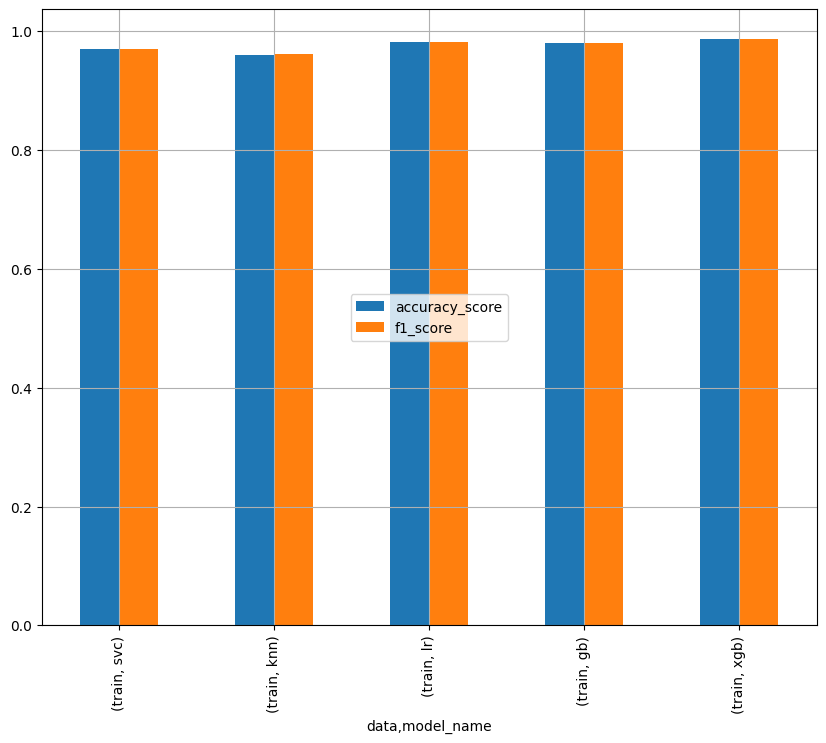

In [32]:
# pandas의 plot 함수을 사용하여 AI모델 별 accuracy_score, f1_score 수직 그래프 시각화
# grid 추가
# legend 위치 center

plt.rcParams["figure.figsize"] = (10,8)
result_comp.plot(kind='bar')
plt.grid()
plt.legend(loc='center')
#plt.savefig('data_model.png')
plt.show()

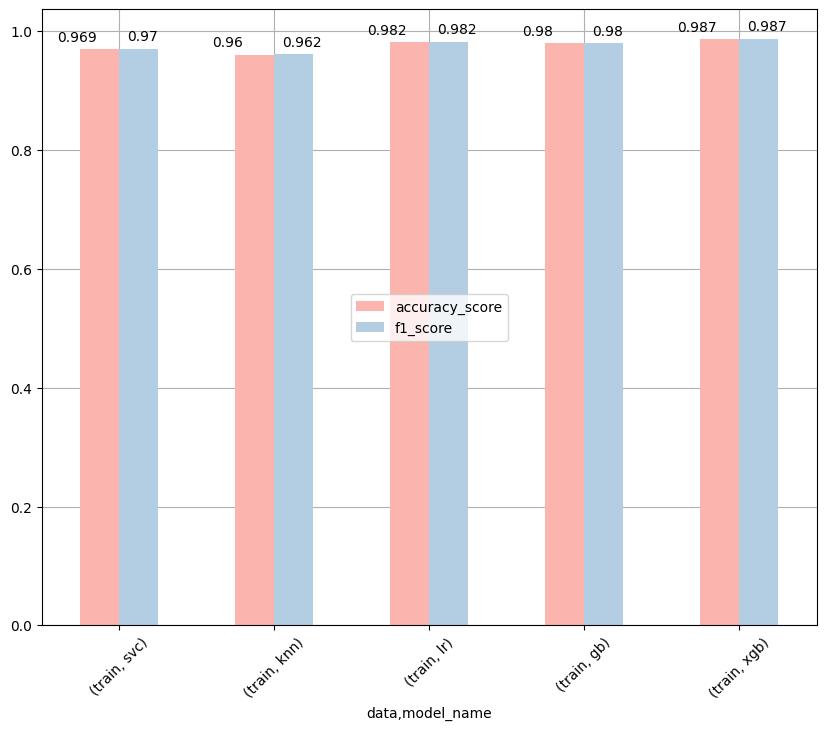

In [33]:
colors = sns.color_palette('Pastel1')

result_comp.plot(color=colors,kind='bar',zorder=2)
for i in range(0,5) :
    plt.text(i-0.4,result.loc[i, 'accuracy_score']+0.02, str(round(result.loc[i, 'accuracy_score'], 3)), va='center')
    plt.text(i+0.05,result.loc[i, 'f1_score']+0.02, str(round(result.loc[i, 'f1_score'], 3)), va='center')
plt.xticks(rotation=45)
plt.grid(zorder=1)
plt.legend(loc='center')
plt.show()

# 미션4 : 모델 튜닝


### (0) 미션 이해하기
   * AI 모델은 튜닝을 통해 더 높은 정확도를 도출할 수 있습니다.
   * Hyper Parameter Tuning 튜닝기법과 Feature Selection 튜닝기법을 사용해 더 높은 정확도를 도출해 보세요.<br>

      - Hyper Parameter Tuning: AI 모델 학습시 매개변수를 조정하여 최상의 성능을 발휘할 수 있는 매개변수를 찾는 방법
      
      - Feature Selection: 모델링 시 raw data의 모든 feature를 사용하는 것은 computing power와 memory 측면에서 매우 비효율적이기 때문에 일부 영향도가 높은 중요 feature만 선택 후 학습하여 모델의 성능을 높이는 방법
   



---

### (1) 데이터 불러오기
* pandas, numpy, matplotlib, seaborn, os 등 데이터 분석에 필요한 라이브러리와 모듈을 불러오세요.
* 라이브러이가 없을땐 !pip 명령어를 통해 라이브러리를 설치 하세요.
* 현위치 하위 'data' 폴더에서 'train_data.csv' 파일 읽어 오세요.

	- 실습순서: 라이브러리 불러오기 -> 현재 디렉토리 확인 -> train_data.csv 불러오기 -> 'subject' 제거 -> result3.csv 불러오기

In [34]:
# pandas, numpy, matplotlib, seaborn, os 등 필요 라이브러리 호출
# 데이터를 나누기 위한 sklearn.model_selection 모듈의 train_test_split 함수 사용
# 모델 성능 평가 출력을 위해 sklearn.metrics 모듈의 모든 클래스 사용

import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import *



* train 데이터 불러오기

In [35]:
# 현재 디렉토리 위치 확인
os.listdir('data')

['admission_simple.csv',
 'airline_satisfaction.csv',
 'airquality.csv',
 'attrition.csv',
 'attrition2.csv',
 'boston.csv',
 'cars.csv',
 'carseats.csv',
 'diabetes.csv',
 'features.csv',
 'income_happy.csv',
 'insurance.csv',
 'iris.csv',
 'mobile_cust_churn.csv',
 'real_data.csv',
 'result3.csv',
 'test_data.csv',
 'titanic_train.csv',
 'train_data.csv']

In [36]:
# 'data' 폴더에서 train_data.csv 파일을 불러와서 data 변수에 할당
# 잘 할당 되었는지 데이터 확인

data = pd.read_csv('data/train_data.csv')
data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,21,STANDING
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,15,LAYING
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,11,STANDING
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,17,WALKING
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,17,WALKING_DOWNSTAIRS


In [37]:
# data 변수(데이터셋)에서 행동분류에 불필요한 'subject'열 제거
# 'subject'열이 잘 제거 되었는지 확인

data.drop('subject', axis=1, inplace=True)
data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.487737,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,STANDING
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.237820,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,LAYING
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.535287,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,STANDING
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.004012,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,WALKING
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.157832,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,WALKING_DOWNSTAIRS


* result 데이터 불러오기

In [38]:
# 모델별 정확도를 비교 할 수 있도록 결과 저장 파일 호출 
# result 변수에 'data' 폴더에서 result3.csv 파일을 불러와서 할당
# 잘 불러와 졌는지 확인

result=pd.read_csv('data/result3.csv')
result

,data,model_name,accuracy_score,f1_score
0,train,svc,0.969405,0.970494
1,train,knn,0.960340,0.961864
2,train,lr,0.981870,0.982488
3,train,gb,0.979603,0.980417
4,train,xgb,0.986969,0.987267


### (2) HyperParameter Tuning

	- 실습순서: 라이브러리 호출-> 데이터 분할/가공 -> Grid Search -> XGBoost 하이퍼파라미터 적용 모델링 -> 결과 출력

* #### XGBoost Hyper Parameter Tuning
    - GridSearchCV 클래스를 사용하여 최고의 성능을 내기위한 파라미터를 찾고 모델링에 적용 해보세요.
    - 튜닝 전/후의 정확도를 비교해 보세요.


In [39]:
# XGBClassifier 알고리즘 사용을 위한 모듈 추가
# GridSearchCV 모듈을 사용하기 위한 모듈 추가(scikit-learn 라이브러리에 포함)

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

In [40]:
# x, y 데이터 나누기 (target = 'Activity')

y = data['Activity']
X = data.drop('Activity', axis=1)
X_train, X_val, y_train, y_val = train_test_split(X,y,train_size=0.7,random_state=2026)

In [41]:
# XGBoost 는 문자형 데이터로 학습할 수 없습니다. 
# y_map 변수를 생성해서 target 데이터(y)를 숫자형 형태로 치환하여 할당
# 데이터 치환 함수: map
# 치환 데이터: 'STANDING':0, 'SITTING':1, 'LAYING':2, 'WALKING':3, 'WALKING_UPSTAIRS':4, 'WALKING_DOWNSTAIRS':5

mapping = {'STANDING':0, 'SITTING':1, 'LAYING':2, 'WALKING':3, 'WALKING_UPSTAIRS':4, 'WALKING_DOWNSTAIRS':5}

y_map = y.map(mapping)
y_map

0       0
1       2
2       0
3       3
4       5
       ..
5876    1
5877    4
5878    2
5879    4
5880    1
Name: Activity, Length: 5881, dtype: int64

In [42]:
# X,y_map를 사용하여 학습 데이터 분할 비율: 학습데이터 7 : 검증데이터 3
# random_state=2026

X_train, X_val, y_train, y_val = train_test_split(X,y_map,train_size=0.7,random_state=2026)

* GridSearchCV 로 하이퍼 파라미터 찾기

In [43]:
# 파라미터 그리드를 생성할 params 변수 생성 후 파라미터의 범위를 할당
# 파라미터 범위: {'learning_rate': [0.01, 0.1, 0.3], 'max_depth': [2,3,4]}
# xgb_model 변수에 XGBClassifier 초기화(random_state=2026)
# GridSearchCV에 파라미터를 넣고 모델 학습
# 파라미터: estimator=xgb_model, param_grid=params, cv = 3, verbose=2
# GridSearchCV가 적용된 모델의 변수명은 'gs_xgb_model'
# GridSearchCV가 적용된 모델의 예측결과 변수명은 'gs_xgb_pred'
# 제대로 학습 되었는지 예측결과 확인
# 그리드 서칭은 실습 노트북 기준 약 10분 소요


params = {'learning_rate': [0.01, 0.1, 0.3], 'max_depth': [2,3,4] }
xgb_model = XGBClassifier(random_state=2026)
gs_xgb_model = GridSearchCV(estimator=xgb_model, param_grid=params, cv = 3, verbose=2)      # verbose=2 : 학습 진행 로그 출력
gs_xgb_model.fit(X_train, y_train)
gs_xgb_pred = gs_xgb_model.predict(X_val)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END ....................learning_rate=0.01, max_depth=2; total time=  10.4s
[CV] END ....................learning_rate=0.01, max_depth=2; total time=   9.3s
[CV] END ....................learning_rate=0.01, max_depth=2; total time=   9.2s
[CV] END ....................learning_rate=0.01, max_depth=3; total time=  17.6s
[CV] END ....................learning_rate=0.01, max_depth=3; total time=  15.0s
[CV] END ....................learning_rate=0.01, max_depth=3; total time=  14.3s
[CV] END ....................learning_rate=0.01, max_depth=4; total time=  19.2s
[CV] END ....................learning_rate=0.01, max_depth=4; total time=  20.0s
[CV] END ....................learning_rate=0.01, max_depth=4; total time=  18.2s
[CV] END .....................learning_rate=0.1, max_depth=2; total time=  13.0s
[CV] END .....................learning_rate=0.1, max_depth=2; total time=  11.6s
[CV] END .....................learning_rate=0.1, 

In [44]:
# 모델 평가 출력(accuracy_score, confusion_matrix, classification_report)
print('accuracy_score: ',accuracy_score(y_val,gs_xgb_pred))

print('\n confusion_matrix: \n',confusion_matrix(y_val,gs_xgb_pred))

print('\n classification_report: \n',classification_report(y_val,gs_xgb_pred))

accuracy_score:  0.9869688385269122

 confusion_matrix: 
 [[316  14   0   0   0   0]
 [  8 287   0   0   0   0]
 [  0   0 330   0   0   0]
 [  0   0   0 303   0   0]
 [  0   0   0   0 271   0]
 [  0   0   0   0   1 235]]

 classification_report: 
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       330
           1       0.95      0.97      0.96       295
           2       1.00      1.00      1.00       330
           3       1.00      1.00      1.00       303
           4       1.00      1.00      1.00       271
           5       1.00      1.00      1.00       236

    accuracy                           0.99      1765
   macro avg       0.99      0.99      0.99      1765
weighted avg       0.99      0.99      0.99      1765



In [45]:
# GridSearchCV 실행 후 최적의 성능 모델링에 사용된 베스트 파라미터 확인
# 참고 함수: .best_params_

print(gs_xgb_model.best_params_)

{'learning_rate': 0.3, 'max_depth': 3}


* xgb 튜닝 모델 학습

In [46]:
# 베스트 파라미터를 적용한 xgb 모델 선언(초기화), 학습, 예측
# AI모델 변수명: xgb_hpt_model 예측결과 변수명: xgb_hpt_pred
# random_state=2026

# 1차적으로 튜닝된 파라미터를 가지고 객체 생성
xgb_hpt_model = XGBClassifier(learning_rate=0.3, max_depth=3)

# 학습
xgb_hpt_model.fit(X_train, y_train)

# 예측
xgb_hpt_pred = gs_xgb_model.predict(X_val)


In [47]:
# 모델 평가 출력(accuracy_score, confusion_matrix, classification_report)
print('accuracy_score: ',accuracy_score(y_val,xgb_hpt_pred))

print('\n confusion_matrix: \n',confusion_matrix(y_val,xgb_hpt_pred))

print('\n classification_report: \n',classification_report(y_val,xgb_hpt_pred))

accuracy_score:  0.9869688385269122

 confusion_matrix: 
 [[316  14   0   0   0   0]
 [  8 287   0   0   0   0]
 [  0   0 330   0   0   0]
 [  0   0   0 303   0   0]
 [  0   0   0   0 271   0]
 [  0   0   0   0   1 235]]

 classification_report: 
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       330
           1       0.95      0.97      0.96       295
           2       1.00      1.00      1.00       330
           3       1.00      1.00      1.00       303
           4       1.00      1.00      1.00       271
           5       1.00      1.00      1.00       236

    accuracy                           0.99      1765
   macro avg       0.99      0.99      0.99      1765
weighted avg       0.99      0.99      0.99      1765



In [48]:
# result 변수(데이터프레임) 마지막에 xgb 튜닝 모델 평가결과 추가 
# 할당할 정보는 데이터명('train'), 모델명('xgb_hpt'), 'accuracy_score', 'f1_score' 예측 결과 할당
# 정확히 구성되었나 확인

result = pd.concat([result, pd.DataFrame([{'data':'train','model_name':'xgb_hpt','accuracy_score':accuracy_score(y_val, xgb_hpt_pred), 'f1_score': f1_score(y_val, xgb_hpt_pred, average = 'macro')}])], ignore_index=True)
result

,data,model_name,accuracy_score,f1_score
0,train,svc,0.969405,0.970494
1,train,knn,0.960340,0.961864
2,train,lr,0.981870,0.982488
3,train,gb,0.979603,0.980417
4,train,xgb,0.986969,0.987267
5,train,xgb_hpt,0.986969,0.987581


### (3) Feature Selection

* Feature Selection 기법을 사용하여 모델을 학습 시켜보세요.
* 중요도 상위 95개, 중요도 상위 50개의 feature 데이터를 선별하여 모델을 학습시켜 보세요.
* 사용할 AI 알고리즘은 가장 정확도가 높았던 XGBoost에 하이퍼파라미터를 적용하여 학습 시킵니다.
* result 변수에 저장된 그동안 학습한 모델 결과와 Feature Selection 기법을 사용한 모델의 정확도를 비교해 보세요.

	- 실습순서: 중요도 데이터프레임 생성-> 데이터 분할/가공 -> Feature Selection(상위 95 순위 까지 Features) -> Feature Selection(상위 50 순위까지 Features) -> 최적의 Feature Selection 찾기 -> 모델링-> 결과 저장

* Feature Selection을 위한 변수별 중요도 추출

In [49]:
# importance_sort 데이터프레임 변수 생성 초기화

importance_sort = pd.DataFrame()

In [50]:
# importance_sort['feature_name'] 열에 모델링에서 사용한 x 데이터프레임의 컬럼명을 할당

importance_sort['feature_name'] = X.columns
importance_sort

,feature_name
0,tBodyAcc-mean()-X
1,tBodyAcc-mean()-Y
2,tBodyAcc-mean()-Z
3,tBodyAcc-std()-X
4,tBodyAcc-std()-Y
...,...
556,"angle(tBodyGyroMean,gravityMean)"
557,"angle(tBodyGyroJerkMean,gravityMean)"
558,"angle(X,gravityMean)"
559,"angle(Y,gravityMean)"


In [51]:
# importance_sort['feature_importance'] 열에 앞에서 사용한 xgb_hpt_model 모델의 feature_importances 를 할당
# 참고함수: feature_importances_

importance_sort['feature_importance'] = xgb_hpt_model.feature_importances_
importance_sort

,feature_name,feature_importance
0,tBodyAcc-mean()-X,0.000020
1,tBodyAcc-mean()-Y,0.000016
2,tBodyAcc-mean()-Z,0.000009
3,tBodyAcc-std()-X,0.000542
4,tBodyAcc-std()-Y,0.000052
...,...,...
556,"angle(tBodyGyroMean,gravityMean)",0.000189
557,"angle(tBodyGyroJerkMean,gravityMean)",0.001011
558,"angle(X,gravityMean)",0.000198
559,"angle(Y,gravityMean)",0.012125


In [52]:
# importance_sort['feature_importance'] 를 내림차순 정열(기준열='feature_importance', 내림차순)
# 참고함수: sort_values

importance_sort.sort_values(by='feature_importance', ascending=False)

,feature_name,feature_importance
40,tGravityAcc-mean()-X,0.074600
296,fBodyAcc-skewness()-X,0.070426
330,"fBodyAcc-bandsEnergy()-1,8.2",0.066614
504,fBodyAccMag-mad(),0.063345
503,fBodyAccMag-std(),0.057039
...,...,...
534,fBodyBodyGyroMag-energy(),0.000000
530,fBodyBodyGyroMag-mad(),0.000000
529,fBodyBodyGyroMag-std(),0.000000
7,tBodyAcc-mad()-Y,0.000000


In [53]:
# feature_importance 내림차순 정렬 때문에 엉킨 인덱스 재설정
# 참고함수: reset_index
# 파라미터: drop=True, inplace=True
# 제대로 정렬 되었는지 데이터 프레임에 확인


importance_sort=importance_sort.sort_values(by='feature_importance', ascending=False)
importance_sort.reset_index(drop=True, inplace=True)
importance_sort

,feature_name,feature_importance
0,tGravityAcc-mean()-X,0.074600
1,fBodyAcc-skewness()-X,0.070426
2,"fBodyAcc-bandsEnergy()-1,8.2",0.066614
3,fBodyAccMag-mad(),0.063345
4,fBodyAccMag-std(),0.057039
...,...,...
556,fBodyBodyGyroMag-energy(),0.000000
557,fBodyBodyGyroMag-mad(),0.000000
558,fBodyBodyGyroMag-std(),0.000000
559,tBodyAcc-mad()-Y,0.000000


* 중요도 상위 95개의 Features 선별 학습

In [54]:
# importance_95 변수에 중요도로 정렬된 importance_sort['feature_importance']의 상위 95 순위의 feature_name 을 할당
# 인덱스 번호가 낮을 수록 중요도 순위가 높은 feature

importance_95 = importance_sort['feature_name'][:95]
importance_95

0                   tGravityAcc-mean()-X
1                  fBodyAcc-skewness()-X
2           fBodyAcc-bandsEnergy()-1,8.2
3                      fBodyAccMag-mad()
4                      fBodyAccMag-std()
                     ...                
90    fBodyAccJerk-bandsEnergy()-41,48.2
91                fBodyGyro-skewness()-X
92               tBodyGyro-arCoeff()-X,1
93          fBodyAcc-bandsEnergy()-1,8.1
94                     fBodyGyro-max()-Y
Name: feature_name, Length: 95, dtype: str

- 슬라이싱 참고 사이트: https://bearwoong.tistory.com/entry/%ED%8C%8C%EC%9D%B4%EC%8D%AC-DataFrame-%EC%9D%B8%EB%8D%B1%EC%8B%B1-%ED%95%98%EB%8A%94-%EB%B0%A9%EB%B2%95df-dfloc-dfiloc

In [55]:
# 훈련 데이터 생성
# x_train_95 변수에 X_train 에서 중요 feature 상위 95 순위 데이터 할당  
# x_val_95 변수에 X_val 에서 중요 feature 상위 95 순위 데이터  할당
# 상위 95순위 직접 인덱싱은 importance_95 사용할 것

x_train_95 = X_train[importance_95]
x_val_95 = X_val[importance_95]

In [57]:
# XGBClassifier 모델 초기화,학습,예측
# AI모델 변수명: xgb95_model , 예측결과 변수명: xgb95_pred
# random_state=2026

xgb95_model = XGBClassifier(learning_rate=0.3, max_depth=3,random_state=2026)

# 학습
xgb95_model.fit(x_train_95, y_train)

# 예측
xgb95_pred = xgb95_model.predict(x_val_95)

In [58]:
# 모델 평가 출력(accuracy_score, confusion_matrix, classification_report)
print('accuracy_score: ',accuracy_score(y_val,xgb95_pred))

print('\n confusion_matrix: \n',confusion_matrix(y_val,xgb95_pred))

print('\n classification_report: \n',classification_report(y_val,xgb95_pred))

accuracy_score:  0.9869688385269122

 confusion_matrix: 
 [[315  15   0   0   0   0]
 [  4 291   0   0   0   0]
 [  0   0 330   0   0   0]
 [  0   0   0 302   1   0]
 [  0   0   0   1 270   0]
 [  0   0   0   1   1 234]]

 classification_report: 
               precision    recall  f1-score   support

           0       0.99      0.95      0.97       330
           1       0.95      0.99      0.97       295
           2       1.00      1.00      1.00       330
           3       0.99      1.00      1.00       303
           4       0.99      1.00      0.99       271
           5       1.00      0.99      1.00       236

    accuracy                           0.99      1765
   macro avg       0.99      0.99      0.99      1765
weighted avg       0.99      0.99      0.99      1765



In [59]:
# result.loc[6,'accuracy_score'] = accuracy_score(y_val, xgb95_pred)
# result.loc[6,'f1_score'] = f1_score(y_val, xgb95_pred, average = 'macro')
# result

In [60]:
# result 변수에 result 데이터프레임 마지막에 모델 평가 결과 추가 (append 함수는 inplace 파라미터가 없음)
# 할당할 정보는 데이터명('train'), 모델명('xgb95_hpt'), 'accuracy_score', 'f1_score' 예측 결과 할당
# 정확히 구성되었나 확인

result = pd.concat([result, pd.DataFrame([{'data':'train','model_name':'xgb95_hpt','accuracy_score':accuracy_score(y_val, xgb95_pred), 'f1_score': f1_score(y_val, xgb95_pred, average = 'macro')}])], ignore_index=True)
result

,data,model_name,accuracy_score,f1_score
0,train,svc,0.969405,0.970494
1,train,knn,0.960340,0.961864
2,train,lr,0.981870,0.982488
3,train,gb,0.979603,0.980417
4,train,xgb,0.986969,0.987267
5,train,xgb_hpt,0.986969,0.987581
6,train,xgb95_hpt,0.986969,0.987398


* 중요도 상위 50개 데이터 모델링(Feature Selection 사용)

In [61]:
# importance_50 변수에 중요도로 정렬된 importance_sort 데이터프레임의 feature_importance 상위 50 순위의 feature_name 을 할당
# 인덱스 번호가 낮을 수록 중요도 순위가 높은 feature

importance_50 = importance_sort['feature_name'][:50]
importance_50

0                   tGravityAcc-mean()-X
1                  fBodyAcc-skewness()-X
2           fBodyAcc-bandsEnergy()-1,8.2
3                      fBodyAccMag-mad()
4                      fBodyAccMag-std()
5                    tGravityAcc-min()-X
6              tGravityAcc-arCoeff()-Z,2
7                       tBodyAcc-iqr()-X
8                   tBodyGyro-energy()-Z
9                    tBodyAcc-energy()-X
10             fBodyBodyAccJerkMag-max()
11                      tBodyAcc-max()-X
12             tGravityAcc-arCoeff()-Z,1
13                 tBodyGyroJerk-mad()-X
14    fBodyAccJerk-bandsEnergy()-17,32.2
15                     fBodyGyro-mad()-X
16                  tBodyAccJerk-iqr()-Y
17                   tGravityAcc-min()-Y
18             fBodyBodyAccJerkMag-std()
19             tBodyGyroJerk-entropy()-X
20       fBodyGyro-bandsEnergy()-49,56.2
21                  angle(Y,gravityMean)
22                      fBodyAcc-max()-X
23         fBodyAcc-bandsEnergy()-9,16.2
24             t

In [62]:
# 훈련 데이터 생성
# x_train_50 변수에X_train 에서 중요 feature 상위 50 순위 데이터 할당  
# x_val_50 변수에 X_val 에서 중요 feature 상위 50 순위 데이터  할당
# 상위 50순위 직접 인덱싱은 importance_50 사용할 것

x_train_50 = X_train[importance_50]
x_val_50 = X_val[importance_50]

In [63]:
# XGBClassifier 모델 초기화,학습,예측
# AI모델 변수명: xgb50_model , 예측결과 변수명: xgb50_pred
# random_state=2026

xgb50_model = XGBClassifier(learning_rate=0.3, max_depth=3,random_state=2026)

# 학습
xgb50_model.fit(x_train_50, y_train)

# 예측
xgb50_pred = xgb50_model.predict(x_val_50)


In [64]:
# 모델 평가 출력(accuracy_score, confusion_matrix, classification_report)

print('accuracy_score: ',accuracy_score(y_val,xgb50_pred))

print('\n confusion_matrix: \n',confusion_matrix(y_val,xgb50_pred))

print('\n classification_report: \n',classification_report(y_val,xgb50_pred))

accuracy_score:  0.9801699716713881

 confusion_matrix: 
 [[312  18   0   0   0   0]
 [  9 286   0   0   0   0]
 [  0   0 330   0   0   0]
 [  0   0   0 300   2   1]
 [  0   0   0   2 269   0]
 [  0   0   0   1   2 233]]

 classification_report: 
               precision    recall  f1-score   support

           0       0.97      0.95      0.96       330
           1       0.94      0.97      0.95       295
           2       1.00      1.00      1.00       330
           3       0.99      0.99      0.99       303
           4       0.99      0.99      0.99       271
           5       1.00      0.99      0.99       236

    accuracy                           0.98      1765
   macro avg       0.98      0.98      0.98      1765
weighted avg       0.98      0.98      0.98      1765



In [65]:
# result 변수에 result 데이터프레임 마지막에 모델 평가 결과 추가 (append 함수는 inplace 파라미터가 없음)
# 할당할 정보는 데이터명('train'), 모델명('xgb50_hpt'), 'accuracy_score', 'f1_score' 예측 결과 할당
# 정확히 구성되었나 확인

result = pd.concat([result, pd.DataFrame([{'data':'train','model_name':'xgb50_hpt','accuracy_score':accuracy_score(y_val, xgb50_pred), 'f1_score': f1_score(y_val, xgb50_pred, average = 'macro')}])], ignore_index=True)
result

,data,model_name,accuracy_score,f1_score
0,train,svc,0.969405,0.970494
1,train,knn,0.960340,0.961864
2,train,lr,0.981870,0.982488
3,train,gb,0.979603,0.980417
4,train,xgb,0.986969,0.987267
5,train,xgb_hpt,0.986969,0.987581
6,train,xgb95_hpt,0.986969,0.987398
7,train,xgb50_hpt,0.980170,0.980668


---
---

<도전미션> 모든 feature로 모델링 했을때와 Feature Selection을 적용해 학습했을때 서로 다른 정확도를 보여 줍니다. 중요도 상위 feature 를 몇 개까지 학습하는게 가장 놓은 정확도를 도출 할 수 있는지 코드를 작성해 보세요.

<도전미션1> Feature Selection 을 사용한 정확도 최고의 학습 feature 개수 선별

	- 실습순서: for 문을 이용하여 중요도 순위 기준 Feature 1개 부터 130개 까지 학습 -> 개수별 학습 정확도 도출 -> plt.plot를 이용한 결과 시각화 -> 최적 학습 Features 개수 선정 -> 모델링 -> 결과 저장

* Feature Selection 을 반복적으로 적용해 최고 정확도의 중요 feature 개수 학습 결과 선별

- 슬라이싱 참고 사이트: https://bearwoong.tistory.com/entry/%ED%8C%8C%EC%9D%B4%EC%8D%AC-DataFrame-%EC%9D%B8%EB%8D%B1%EC%8B%B1-%ED%95%98%EB%8A%94-%EB%B0%A9%EB%B2%95df-dfloc-dfiloc

In [66]:
# acc 데이터 프레임을 생성 및 초기화(컬럼 지정: columns=['accuracy_score'])
# for 문을 사용해 중요도 상위 feature 1개 모델링부터 상위 feature 130개  모델링까지 순차적 모델링 실행 후 각 accuracy_score 결과를 acc 변수에 누적
# 참고: 슬라이싱 할때 [:1] -> index 0 까지 짤림, [:100] -> index 99 까지 짤림, 슬라이싱 할 인덱스 번호 +1 해서 슬라이싱 할 것
# 전체 feature는 561개 이지만, 학습에 130개면 충분(약 10분 소요)
# for 매 회 마다 accuracy_score 결과 출력

acc = pd.DataFrame(columns=['accuracy_score'])

for i in range(130):

    importance_n = importance_sort['feature_name'][:i+1]

    x_train_n = X_train[importance_n]
    x_val_n = X_val[importance_n]

    xgb_n_model = XGBClassifier(learning_rate=0.3, max_depth=3, random_state=2026)
    xgb_n_model.fit(x_train_n, y_train)
    xgb_n_pred = xgb_n_model.predict(x_val_n)
    
    acc.loc[i] = accuracy_score(y_val,xgb_n_pred)
    print(acc.loc[i])

acc

accuracy_score    0.469688
Name: 0, dtype: float64
accuracy_score    0.61983
Name: 1, dtype: float64
accuracy_score    0.709915
Name: 2, dtype: float64
accuracy_score    0.812465
Name: 3, dtype: float64
accuracy_score    0.824363
Name: 4, dtype: float64
accuracy_score    0.827195
Name: 5, dtype: float64
accuracy_score    0.853824
Name: 6, dtype: float64
accuracy_score    0.860057
Name: 7, dtype: float64
accuracy_score    0.874788
Name: 8, dtype: float64
accuracy_score    0.884419
Name: 9, dtype: float64
accuracy_score    0.887252
Name: 10, dtype: float64
accuracy_score    0.887819
Name: 11, dtype: float64
accuracy_score    0.889518
Name: 12, dtype: float64
accuracy_score    0.925212
Name: 13, dtype: float64
accuracy_score    0.932578
Name: 14, dtype: float64
accuracy_score    0.942776
Name: 15, dtype: float64
accuracy_score    0.946742
Name: 16, dtype: float64
accuracy_score    0.974504
Name: 17, dtype: float64
accuracy_score    0.975637
Name: 18, dtype: float64
accuracy_score    0.972

,accuracy_score
0,0.469688
1,0.619830
2,0.709915
3,0.812465
4,0.824363
...,...
125,0.988669
126,0.988669
127,0.986969
128,0.987535


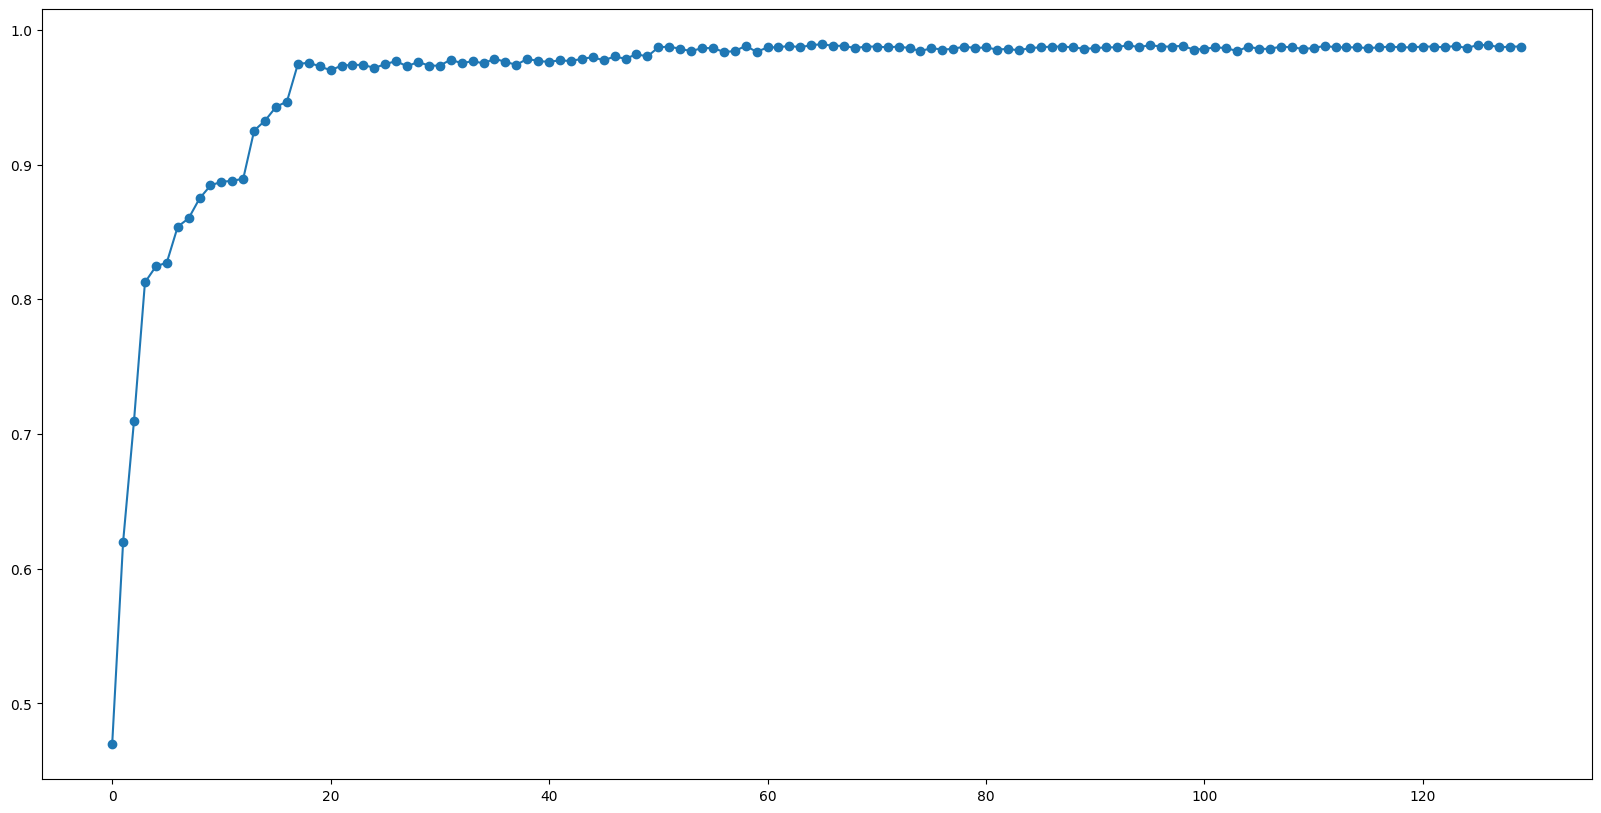

In [67]:
# accuracy_score 누적한 acc 변수 시각화
## 참고 함수: plt.plot

plt.figure(figsize=(20,10))
plt.plot(acc,marker='o')
plt.show()
#accuracy_score

* 정확도 최고의 학습 Feature 개수 찾기

In [68]:
# acc 변수를 accuracy_score 기준 내림차순으로 정렬(인덱스 재설정X)
# accuracy_score 값이 가능 높을때의 인덱스명이 학습된 상위 feature 개수를 뜻함

acc=acc.sort_values(by='accuracy_score', ascending=False)
acc

,accuracy_score
65,0.989235
64,0.988669
125,0.988669
126,0.988669
95,0.988669
...,...
4,0.824363
3,0.812465
2,0.709915
1,0.619830


In [69]:
# importance_top 변수에 acc 에서 확인한 상위 feature 개수 만큼 importance_sort['feature_name']를 슬라이싱 하여 할당
# 참고: 슬라이싱 할때 [:1] -> index 0 까지 짤림, [:100] -> index 99 까지 짤림, 정확도 최고치 인덱스 값 +1 해서 슬라이싱 할 것

importance_top = importance_sort['feature_name'][:acc.index[0]+1]
importance_top

0             tGravityAcc-mean()-X
1            fBodyAcc-skewness()-X
2     fBodyAcc-bandsEnergy()-1,8.2
3                fBodyAccMag-mad()
4                fBodyAccMag-std()
                  ...             
61              fBodyGyro-mean()-Y
62            tBodyAccJerk-iqr()-Z
63     tBodyGyro-correlation()-Y,Z
64          tBodyGyroMag-entropy()
65           fBodyAcc-kurtosis()-Z
Name: feature_name, Length: 66, dtype: str

In [70]:
# 훈련 데이터 생성
# x_train_top 변수에 X_train을 중요 feature 만클 슬라이싱 한 X_train[importance_top] 할당
# x_val_top 변수에 X_val을 중요 feature 만클 슬라이싱 한 X_val[importance_top] 할당

x_train_top = X_train[importance_top]
x_val_top = X_val[importance_top]

In [71]:
# XGBClassifier 모델 초기화,학습,예측
# AI모델 변수명: xgb_top_model , 예측결과 변수명: xgb_top_pred
# random_state=2026

xgb_top_model = XGBClassifier(learning_rate=0.3, max_depth=3,random_state=2026)

# 학습
xgb_top_model.fit(x_train_top, y_train)

# 예측
xgb_top_pred = xgb_top_model.predict(x_val_top)

In [72]:
# 모델 평가 출력(accuracy_score, confusion_matrix, classification_report)

print('accuracy_score: ',accuracy_score(y_val,xgb_top_pred))

print('\n confusion_matrix: \n',confusion_matrix(y_val,xgb_top_pred))

print('\n classification_report: \n',classification_report(y_val,xgb_top_pred))

accuracy_score:  0.9892351274787535

 confusion_matrix: 
 [[317  13   0   0   0   0]
 [  3 292   0   0   0   0]
 [  0   0 330   0   0   0]
 [  0   0   0 302   1   0]
 [  0   0   0   1 270   0]
 [  0   0   0   0   1 235]]

 classification_report: 
               precision    recall  f1-score   support

           0       0.99      0.96      0.98       330
           1       0.96      0.99      0.97       295
           2       1.00      1.00      1.00       330
           3       1.00      1.00      1.00       303
           4       0.99      1.00      0.99       271
           5       1.00      1.00      1.00       236

    accuracy                           0.99      1765
   macro avg       0.99      0.99      0.99      1765
weighted avg       0.99      0.99      0.99      1765



In [73]:
# result 변수에 result 데이터프레임 마지막에 모델 평가 결과 추가 (append 함수는 inplace 파라미터가 없음)
# 할당할 정보는 데이터명('train'), 모델명('xgb_top'), 'accuracy_score', 'f1_score' 예측 결과 할당
# 정확히 구성되었나 확인

result = pd.concat([result, pd.DataFrame([{'data':'train','model_name':'xgb_top','accuracy_score':accuracy_score(y_val, xgb_top_pred), 'f1_score': f1_score(y_val, xgb_top_pred, average = 'macro')}])], ignore_index=True)
result

,data,model_name,accuracy_score,f1_score
0,train,svc,0.969405,0.970494
1,train,knn,0.960340,0.961864
2,train,lr,0.981870,0.982488
3,train,gb,0.979603,0.980417
4,train,xgb,0.986969,0.987267
5,train,xgb_hpt,0.986969,0.987581
6,train,xgb95_hpt,0.986969,0.987398
7,train,xgb50_hpt,0.980170,0.980668
8,train,xgb_top,0.989235,0.989628


---
---

### (4) 결과 저장 및 시각화

In [74]:
result

,data,model_name,accuracy_score,f1_score
0,train,svc,0.969405,0.970494
1,train,knn,0.960340,0.961864
2,train,lr,0.981870,0.982488
3,train,gb,0.979603,0.980417
4,train,xgb,0.986969,0.987267
5,train,xgb_hpt,0.986969,0.987581
6,train,xgb95_hpt,0.986969,0.987398
7,train,xgb50_hpt,0.980170,0.980668
8,train,xgb_top,0.989235,0.989628


In [75]:
# 인덱스 미포함 result 변수를 result4.csv 파일로 저장
# 저장경로: ./data
# 파일명: result4.csv
result.to_csv('data/result4.csv', index=False)

In [76]:
# 잘 저장 되었는지 확인
pd.read_csv('data/result4.csv')

,data,model_name,accuracy_score,f1_score
0,train,svc,0.969405,0.970494
1,train,knn,0.960340,0.961864
2,train,lr,0.981870,0.982488
3,train,gb,0.979603,0.980417
4,train,xgb,0.986969,0.987267
5,train,xgb_hpt,0.986969,0.987581
6,train,xgb95_hpt,0.986969,0.987398
7,train,xgb50_hpt,0.980170,0.980668
8,train,xgb_top,0.989235,0.989628


*  model_name 별 accuracy_score, f1_score 시각화(수직 그래프)


In [77]:
# result_comp 변수에 result 데이터프레임의 data, model_name을 컴럼으로 지정 후 할당
# 참고함수: set_index
# 지정 인덱스: ['data','model_name']

result_comp = result.set_index(['data','model_name'])
result_comp

accuracy_score  f1_score
data  model_name                          
train svc               0.969405  0.970494
      knn               0.960340  0.961864
      lr                0.981870  0.982488
      gb                0.979603  0.980417
      xgb               0.986969  0.987267
      xgb_hpt           0.986969  0.987581
      xgb95_hpt         0.986969  0.987398
      xgb50_hpt         0.980170  0.980668
      xgb_top           0.989235  0.989628

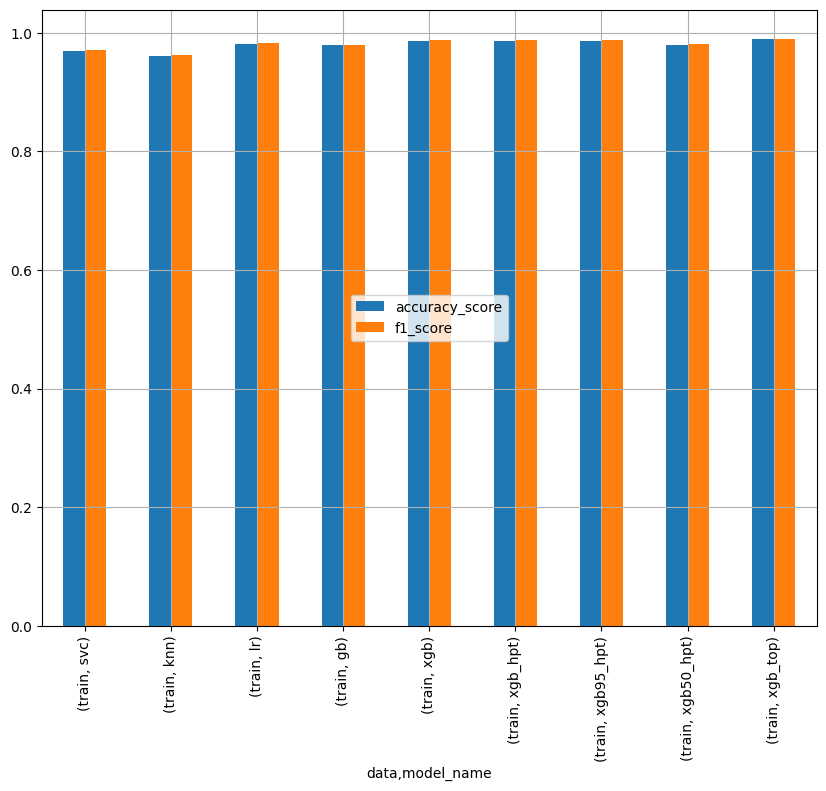

In [78]:
# pandas의 plot 함수을 사용하여 AI모델 별 accuracy_score, f1_score 수직 그래프 시각화
# grid 추가
# legend 위치 center

plt.rcParams["figure.figsize"] = (10,8)
result_comp.plot(kind='bar')
plt.grid()
plt.legend(loc='center')
plt.show()

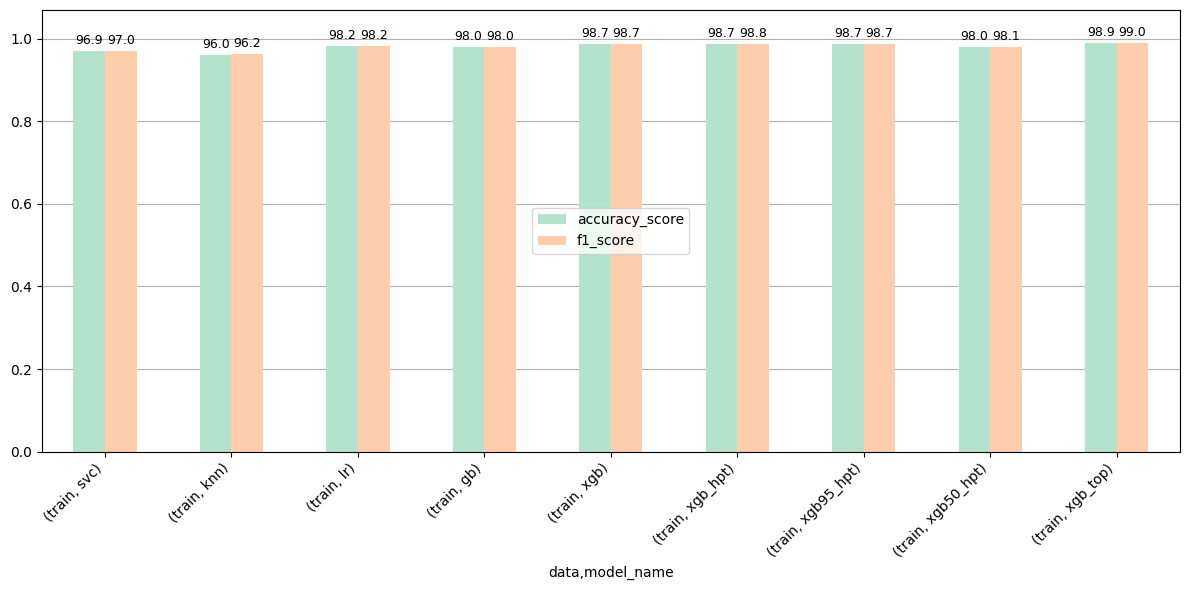

In [79]:
# pandas의 plot 함수을 사용하여 AI모델 별 accuracy_score, f1_score 수직 그래프 시각화
# grid 추가
# legend 위치 center

# 최신 result 데이터 기준으로 result_comp를 다시 생성
result_comp = result.set_index(['data','model_name'])

colors = sns.color_palette('Pastel2', n_colors=len(result_comp.columns))

ax = result_comp.plot(color=colors, kind='bar', zorder=2, figsize=(12,6))

for container in ax.containers:
    labels = [f'{bar.get_height() * 100:.1f}' for bar in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(1.05, result_comp.to_numpy().max() + 0.08))
plt.grid(axis='y', zorder=1)
plt.legend(loc='center')
plt.tight_layout()
plt.show()